# ChatEV: Predicción de la demanda de recarga de vehículos eléctricos mediante el procesamiento del lenguaje natural

### Trabajo Final – Modelado computacional, Simulación y Optimización. Máster en Ciencia de Datos

Autoras: Jimena Milla Moreno, Itsaso Ariztimuño Cenoz

Fuente:    https://github.com/IntelligentSystemsLab/ST-EVCDP

Este trabajo aborda la replicación y análisis crítico del modelo ChatEV, un sistema de predicción de demanda de recarga de vehículos eléctricos (VE) que integra técnicas de procesamiento del lenguaje natural (PLN) con meta-aprendizaje. ChatEV reformula el problema de predicción de series temporales espacio-temporales como una tarea de generación de texto (text-to-text), empleando el modelo T5 como backbone y el algoritmo Reptile como estrategia de meta-aprendizaje.


## 1. Importación de paquetes

In [29]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import T5ForConditionalGeneration, T5Tokenizer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import copy, random, warnings, math, json, re
from pathlib import Path
from scipy.spatial.distance import cdist
import glob
import os
import zipfile, tempfile, warnings
import importlib, subprocess, sys
import geopandas as gpd
from shapely.geometry import LineString

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
MODEL_NAME = "t5-small"

Dispositivo: cuda


## 2. Carga, Validación y Preprocesado del Dataset

In [30]:
# Cargamos datasets — auto-descubre ruta en Drive (sin hardcode)
import os, glob

# Montar Drive si no está montado
try:
    from google.colab import drive
    if not os.path.isdir("/content/drive/MyDrive"):
        drive.mount("/content/drive")
except ImportError:
    pass  # entorno no-Colab

# Auto-descubrir carpeta que contiene information.csv
candidates = glob.glob("/content/drive/**/*information.csv", recursive=True)
if candidates:
    ruta = os.path.dirname(candidates[0])
    print(f"Datasets encontrados en: {ruta}")
else:
    raise FileNotFoundError(
        "information.csv no encontrado en Drive.\n"
        "Sube los CSVs del dataset ST-EVCDP a Google Drive e inténtalo de nuevo."
    )

dfs = {}
for fichero in glob.glob(os.path.join(ruta, "*.csv")):
    nombre = os.path.basename(fichero).replace(".csv", "")
    dfs[nombre] = pd.read_csv(fichero, index_col=0)

print(f"{len(dfs)} datasets cargados: {list(dfs.keys())}") 

Datasets encontrados en: /content/drive/MyDrive/datasets
12 datasets cargados: ['adj', 'distance', 'information', 'occupancy', 'duration', 'volume', 'price', 'time', 'stations', 'calendar_features', 'addresses_shenzhen', 'weather_shenzhen']


### 2.1. Normalización Min-Max por zona

Antes de construir las características del modelo, aplicamos una normalización Min-Max para cada zona de carga. Con este procedimiento transformamos los valores al rango $[0,1]$, permitiendo así que todas las zonas trabajen en una escala comparable independientemente de sus niveles absolutos de ocupación o demanda.

Para evitar el *data leakage*, calculamos los parámetros de normalización (mínimo y máximo) con los datos del conjunto de entrenamiento. Después, utilizamos estos parámetros para transformar toda la serie temporal de la zona, incluyendo los conjuntos de validación y prueba.

Además de la matriz normalizada, la función almacena un objeto `MinMaxScaler` por cada zona. Estos escaladores se pueden utilizar posteriormente para revertir la transformación y expresar las predicciones en la escala original de los datos.

In [31]:
# Normalización Min-Max por zona

def normalizar_zona(arr: np.ndarray, fit_mask: np.ndarray) -> tuple:
  """
  Esta función escala cada zona independientemente usando solo datos
  de training para evitar data leakage.
  Devuelve (arr_norm, scalers_list)
  """

  arr_norm = arr.copy()
  scalers = []  # lista para guardar un MinMaxScaler por cada zona

  for z in range(arr.shape[0]):
    sc = MinMaxScaler(feature_range=(0, 1)) # escalador Min-Max
    sc.fit(arr[z, fit_mask].reshape(-1, 1))
    arr_norm[z] = sc.transform(arr[z].reshape(-1, 1)).flatten()
    scalers.append(sc)
  return arr_norm, scalers

### 2.2. Agregación espacial mediante Graph Message Passing


También incorporamos información espacial de las zonas vecinas mediante una operación de Graph Message Passing. Para ello, utilizamos la matriz de adyacencia, que define las conexiones existentes entre las distintas zonas de carga.

La siguiente función calcula la ocupación media de todas las zonas conectadas a cada zona en cada instante temporal. Este procedimiento es una simplificación de una convolución sobre grafos (Graph Convolution), donde la representación de un nodo se construye agregando la información de sus vecinos:

$$h_i = \frac{1}{|N(i)|}\sum_{j \in N(i)} x_j$$

donde $N(i)$ representa el conjunto de vecinos de la zona $i$ y $x_j$ la ocupación observada en cada zona vecina.

Como resultado obtenemos una nueva serie temporal que resume el comportamiento del entorno espacial de cada estación.

En el caso de que una zona no tenga vecinos definidos en la matriz de adyacencia, utilizamos su propia ocupación como valor de respaldo (*fallback*), garantizando que todas las zonas tengan información espacial válida.

In [32]:
# Graph Message Passing con matriz de adyacencia

def simple_graph_message(occupancy: np.ndarray, adj: np.ndarray, ) -> np.ndarray:
  """
  Esta función agrega la ocupación media de los vecinos reales según adj.csv.
  Implementamos la ecuación de Simple Graph Convolution: h_i = mean_{j \in N(i)} x_j.
  Usamos la adyacencia binaria del dataset en lugar de distancia euclidiana.
  """

  n_zonas = adj.shape[0]
  vecino_occ = np.zeros_like(occupancy)

  for z in range(n_zonas):
    vecinos = np.where(adj[z] == 1)[0]
    # Si no tiene vecinos, usamos su propia ocupación como fallback
    if len(vecinos) == 0:
      vecino_occ[z] = occupancy[z]
    else:
      vecino_occ[z] = occupancy[vecinos].mean(axis=0) # media por columnas

  return vecino_occ

### 2.3. Carga y preparación de los datos

En este apartado, cargamos los siguientes archivos del dataset ST-EVCDP:

- **adj.csv:** La matriz de adyacencia de las zonas estudiadas, 1 indica que las dos zonas de tráfico son contiguas, y viceversa.
- **distance.csv:** Distancias entre nodos.
- **information.csv:** Varios datos básicos sobre los datos, entre ellos la capacidad, la longitud y la latitud de las pilas, si se encuentran o no en el distrito central de negocios (1: sí, 0: no) y si se aplican o no tarifas por tiempo (1: sí, 0: no).
- **occupancy.csv:** La ocupación de los puntos de recarga de vehículos eléctricos en tiempo real en las zonas estudiadas.
- **duration.csv:** La duración de la recarga de vehículos eléctricos en tiempo real en las zonas estudiadas, es decir, la suma del tiempo de recarga de todas las estaciones de recarga, en horas.
- **volume.csv:** El volumen de recarga de vehículos eléctricos en tiempo real en las zonas estudiadas, es decir, el consumo total de energía de todas las estaciones de recarga, expresado en kWh.
- **price.csv:** Las tarifas de recarga de vehículos eléctricos en tiempo real en las zonas analizadas.
- **time.csv:** Las marcas de tiempo del periodo estudiado.

Realizamos una limpieza básica de los datos, normalizando los nombres de las columnas descriptivas y convirtiendo todas las matrices a formato numérico. Además, se procesan los registros temporales para obtener la secuencia completa de timestamps del conjunto de datos.

Por último, reorganizamos las series temporales para garantizar una estructura homogénea con dimensiones (número de zonas × número de instantes temporales), facilitando así su posterior utilización en las etapas de análisis, generación de características y entrenamiento del modelo.

In [33]:
print("Dimensiones de cada csv:")

# Matriz de adyacencia
adj = dfs["adj"].values.astype(np.float32)
print(f" adj.csv -> {adj.shape}")

# Matriz de distancias
dist = dfs["distance"].values.astype(np.float32)
np.fill_diagonal(dist, 0.0)
print(f" distance.csv -> {dist.shape}")

# Información estática
info = dfs["information"].copy()
# limpiamos nombres de las columnas (todo minusculas y sin espacios)
info.columns = [
    c.strip().lower().replace(" ", "_")
    for c in info.columns
]

print(f" information.csv -> {info.shape}")
print(f" columnas: {list(info.columns)}")

# Timestamps
time_df = dfs["time"]

try:
    timestamps = pd.to_datetime(time_df.iloc[:, 0])
except:
    timestamps = pd.RangeIndex(len(time_df))

n_pasos = len(timestamps)

print(f" time.csv -> {n_pasos} pasos")

# Series temporales
def cargar_st(df):
    '''
    función para cargar occupancy, duration, volume y price
    '''
    arr = df.values.astype(np.float32)
    n_zonas = adj.shape[0]

    if arr.shape[0] == n_zonas:
      return arr
    elif arr.shape[1] == n_zonas:
      return arr.T

    return arr

occupancy = cargar_st(dfs["occupancy"]) # tasa [0,1]
duration = cargar_st(dfs["duration"])  # horas
volume = cargar_st(dfs["volume"])  # kWh
price = cargar_st(dfs["price"]) # €/kWh

n_zonas = adj.shape[0]  # numero de zonas

print(f" occupancy.csv -> {occupancy.shape}")
print(f" duration.csv -> {duration.shape}")
print(f" volume.csv -> {volume.shape}")
print(f" price.csv -> {price.shape}")

print(f"\nDataset: {n_zonas} zonas × {n_pasos} timesteps")

Dimensiones de cada csv:
 adj.csv -> (247, 247)
 distance.csv -> (247, 247)
 information.csv -> (247, 9)
 columnas: ['grid', 'count', 'fast_count', 'slow_count', 'area', 'lon', 'la', 'cbd', 'dynamic_pricing']
 time.csv -> 8640 pasos
 occupancy.csv -> (247, 8640)
 duration.csv -> (247, 8640)
 volume.csv -> (247, 8640)
 price.csv -> (247, 8640)

Dataset: 247 zonas × 8640 timesteps


Observamos que el dataset está compuesto por **247 zonas** de carga de vehículos eléctricos.

 La infromación estática contiene **9 características descriptivas por zona**, incluyendo el número de cargadores rápidos y lentos, el área, la localización geográfica y la existencia de precios dinámicos.

 En cuanto a la dimensión temporal, el conjunto de datos contiene **8640 intervalos de tiempo**, correspondientes a registros tomados cada 5 minutos durante 30 días consecutivos. Las variables dinámicas de ocupación, duración de carga, volumen energético y precio presentan una estructura homogénea de $247 \times 8640$, donde cada fila representa una zona y cada columna un instante temporal.

### 2.4. División del conjunto de datos

Una vez calculadas las características espaciales y temporales, dividimos el dataset cronológicamente en tres subconjuntos: entrenamiento (60%), validación (20%) y test (20%).

En este proceso normalizamos las variables de ocupación y precio utilizando los datos del conjunto de entrenamiento, para así evitar problemas de data leakage. Además, calculamos la ocupación media de las zonas vecinas mediante la matriz de adyacencia.

Por último, dividimos las zonas aleatoriamente en dos grupos: seen y unseen. Reservamos las zonas unseen para evaluar la capacidad de generalización espacial del modelo en un escenario zero-shot, es decir, sobre estaciones que no han participado en el ajuste del modelo.

In [34]:
# División cronológica 60(dias 1-18)/20(dias 19-24)/20(dias 35-30) + zonas unseen

raw_data = {
        "adj": adj,
        "dist": dist,
        "info": info,
        "timestamps": timestamps,
        "occupancy": occupancy,
        "duration": duration,
        "volume": volume,
        "price": price,
        "n_zonas": n_zonas,
        "n_pasos": n_pasos,
    }

n_t = raw_data["n_pasos"]
t_train_fin = int(0.60 * n_t)
t_val_fin = int(0.80 * n_t)
time_div = {
  "train": (0, t_train_fin),  # (0,5184)
  "val": (t_train_fin, t_val_fin),  # (5184,6912)
  "test": (t_val_fin, n_t), # (6912,8640)
}

# Normalizar usando solo ventana de entrenamiento
train_mask = np.zeros(n_t, dtype=bool)
train_mask[:t_train_fin] = True

occ_norm, occ_scalers = normalizar_zona(raw_data["occupancy"], train_mask)

# Precio: normalizar a [0,1] para que sea comparable en el prompt
price_norm, _ = normalizar_zona(raw_data["price"], train_mask)

# Vecinos con adj real
vecino_occ = simple_graph_message(occ_norm, raw_data["adj"])

# Separar zonas seen/unseen aleatoriamente
zonas = list(range(raw_data["n_zonas"]))
random.shuffle(zonas)
unseen_ratio = 0.2
n_unseen = max(1, int(unseen_ratio * raw_data["n_zonas"]))
unseen_zonas = zonas[:n_unseen]
seen_zonas = zonas[n_unseen:]

dataset = {
  **raw_data,
  "occ_norm": occ_norm,
  "occ_scalers": occ_scalers,
  "price_norm": price_norm,
  "vecino_occ": vecino_occ,
  "seen_zonas": seen_zonas,
  "unseen_zonas": unseen_zonas,
  "time_div": time_div,
}

print(f"- Zonas totales: {dataset['n_zonas']}")
print(f"- Zonas vistas: {len(dataset['seen_zonas'])}")
print(f"- Zonas no vistas: {len(dataset['unseen_zonas'])}")
ts = dataset["time_div"]
print(f"- Train t[0:{ts['train'][1]}], Val t[{ts['val'][0]}:{ts['val'][1]}], Test t[{ts['test'][0]}:{ts['test'][1]}]")

- Zonas totales: 247
- Zonas vistas: 198
- Zonas no vistas: 49
- Train t[0:5184], Val t[5184:6912], Test t[6912:8640]


El conjunto de datos contiene un total de 247 zonas, de las cuales 198 se utilizan durante el entrenamiento y 49 se reservan como zonas no vistas para evaluar la capacidad de generalización espacial del modelo. Además, como hemos mencionado anteriormente, la serie temporal se divide cronológicamente en un 60% para entrenamiento (0–5184), un 20% para validación (5184–6912) y un 20% para prueba (6912–8640), evitando el uso de información futura durante el aprendizaje.

### 2.5. Análisis exploratorio

A continuación, realizamos una exploración visual del dataset mediante tres representaciones: la distribución de los niveles de ocupación, la evolución temporal de la ocupación media frente a una zona concreta y la estructura espacial de la red a través de la matriz de adyacencia.

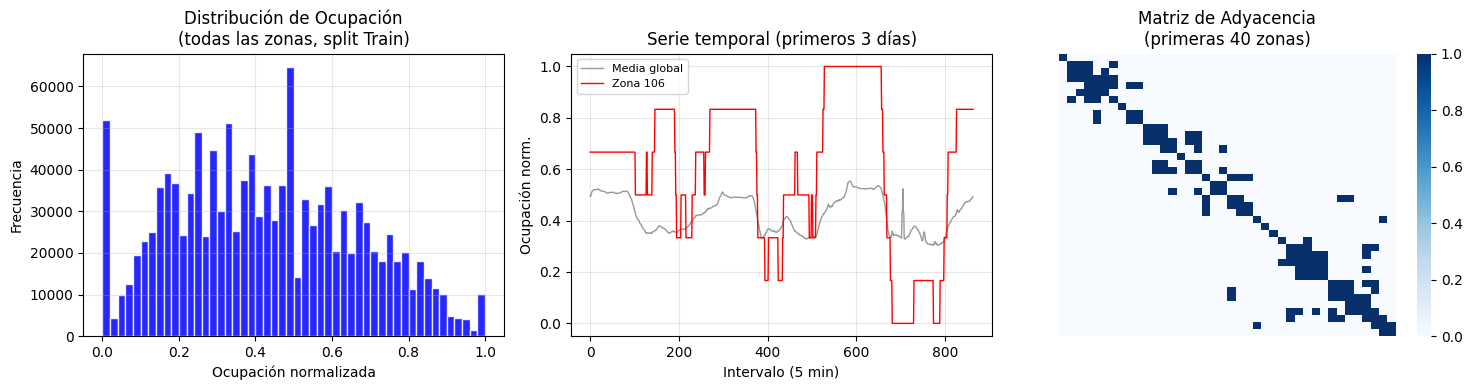

In [35]:
fig0, axes0 = plt.subplots(1, 3, figsize=(15, 4))

# Histograma de tasas de ocupación
ts0, te0 = ts["train"]
occ_flat = dataset["occ_norm"][:, ts0:te0].flatten()
axes0[0].hist(occ_flat, bins=50, color="blue", edgecolor="white", alpha=0.85)
axes0[0].set_xlabel("Ocupación normalizada")
axes0[0].set_ylabel("Frecuencia")
axes0[0].set_title("Distribución de Ocupación\n(todas las zonas, split Train)")
axes0[0].grid(alpha=0.3)

# Serie temporal promedio global vs una zona concreta (3 días)
mean_occ = dataset["occ_norm"].mean(axis=0) # occ media global
sample_z = dataset["seen_zonas"][0] # 1ª zona de train
# 24*12*3 = 24h x 12 muestras/h * 3 dias
axes0[1].plot(mean_occ[:288*3], color="gray", lw=1, label="Media global", alpha=0.8)
axes0[1].plot(dataset["occ_norm"][sample_z, :288*3],
              color="red", lw=1, label=f"Zona {sample_z}")
axes0[1].set_xlabel("Intervalo (5 min)")
axes0[1].set_ylabel("Ocupación norm.")
axes0[1].set_title("Serie temporal (primeros 3 días)")
axes0[1].legend(fontsize=8)
axes0[1].grid(alpha=0.3)

# Mapa de calor de la matriz de adyacencia (primeras 40 zonas)
sub = dataset["adj"][:40, :40]
sns.heatmap(sub, ax=axes0[2], cmap="Blues", cbar=True,
            xticklabels=False, yticklabels=False, linewidths=0)
axes0[2].set_title("Matriz de Adyacencia\n(primeras 40 zonas)")
plt.tight_layout()
plt.show()

- **Distribución de ocupación:** El histograma nos muestra que los valores de ocupación normalizada se distribuyen a lo largo de todo el rango [0,1], aunque existe una mayor cantidad en valores del medio. También observamos valores altos en determinados niveles de ocupación, lo que nos sugiere que algunas estaciones permanecen con frecuencia en estados concretos de utilización.

- **Serie temporal:** Si comparamos la ocupación media global (gris) con una zona concreta (rojo) durante los tres primeros días, vemos comportamientos diferentes entre estaciones. Mientras que la media global tiene variaciones suaves y estables, la zona concreta tiene cambios bruscos y periodos prolongados en niveles altos o bajos de ocupación. Esto nos indica que existen patrones locales específicos que no quedan completamente reflejados por la tendencia global.

- **Matriz de adyacencia:** El mapa de calor nos da una estructura de red dispersa, donde cada zona está conectada con un número reducido de vecinas. Además, hay bloques de conexiones más densas, lo que nos sugiere la presencia de comunidades espaciales dentro de la red.



### 2.6. Visualización espacial de las zonas TAZ de Shenzhen

Con el objetivo de analizar la estructura espacial utilizada por el modelo ST-EVCDP, realizamos una exploración geográfica de las Traffic Analysis Zones (TAZ) incluidas en el conjunto de datos de Shenzhen. Para ello, cargamos la capa cartográfica `SZ_districts.shp` mediante GeoPandas y  reproyectamos al sistema de coordenadas WGS84 (EPSG:4326), lo que nos permite representar las zonas en coordenadas geográficas de latitud y longitud.

A partir de la geometría de cada zona calculamos sus centroides, que utilizamos posteriormente para construir el grafo de adyacencia espacial definido en el conjunto de datos. Este grafo representa las relaciones de vecindad entre zonas y constituye una de las principales fuentes de información espacial del modelo.

Además, cuando los datos de ocupación están disponibles, calculamos la ocupación media temporal de cada zona y lo incorporamos como atributo de la capa geográfica, permitiendo visualizar la distribución espacial de la demanda de recarga. Finalmente, generamos dos representaciones complementarias: un mapa temático de las zonas coloreadas según su ocupación media y una visualización del grafo de adyacencia sobre el territorio, junto con estadísticas descriptivas de la capa y la identificación de las zonas utilizadas para la evaluación en escenarios zero-shot.


Número de zonas del shapefile: 10
CRS original: EPSG:3857
Columnas: ['name', 'geometry']
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]

Información dataset:
Nº zonas dataset: 247
Occupancy shape: (247, 8640)
Adjacency shape: (247, 247)
Nº aristas del grafo: 503

ESTADÍSTICAS SHAPEFILE
------------------------
                   name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

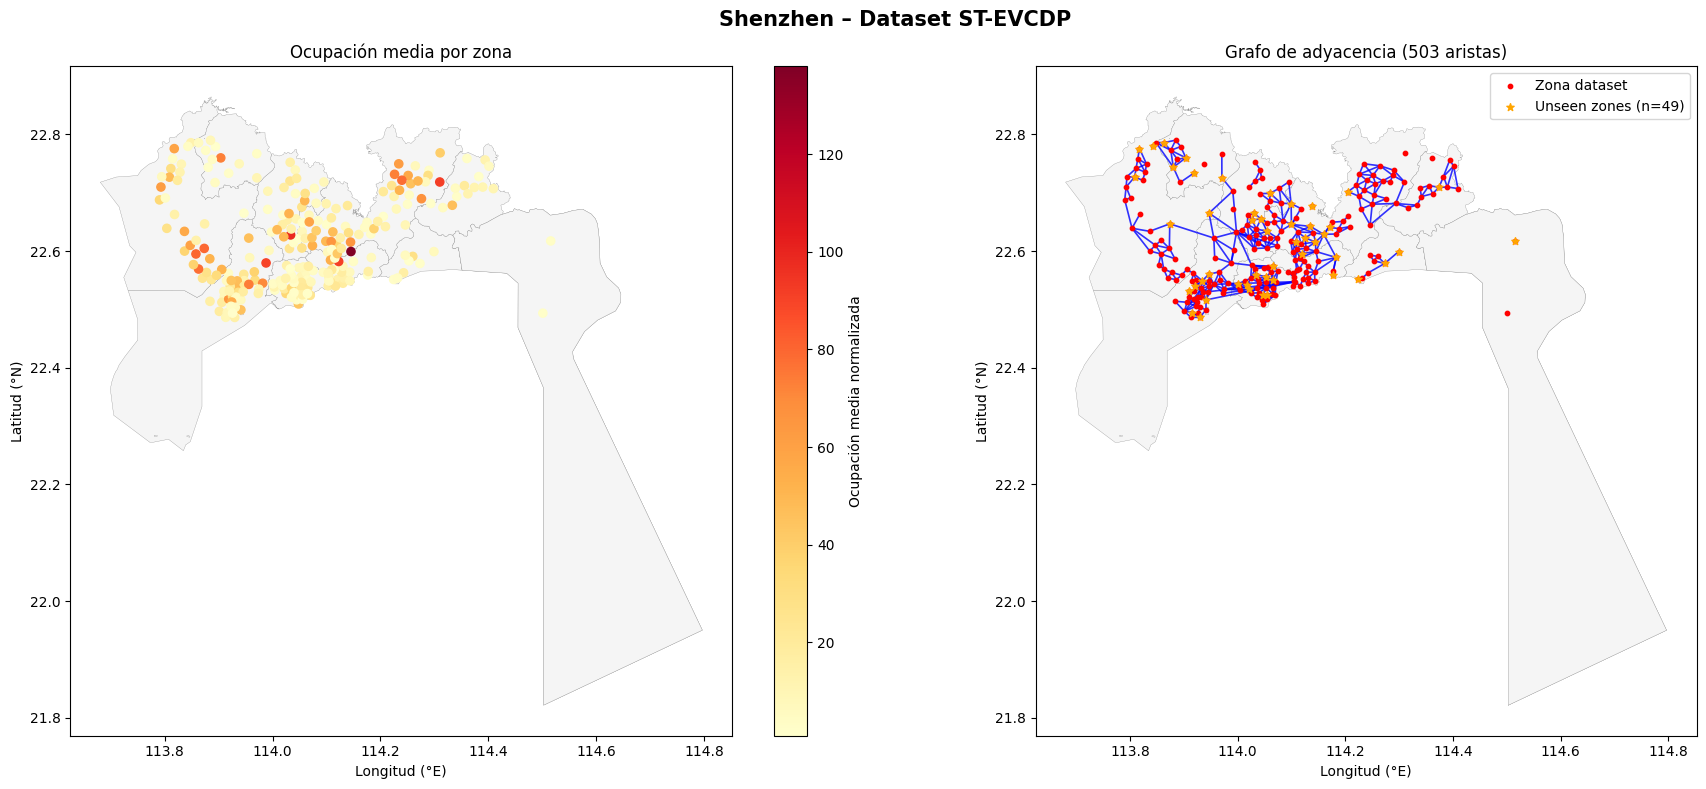

In [36]:
# shapefile de shenzhen
import os

ruta_shp = os.path.join(ruta, "SZ_districts", "SZ_districts.shp")

if not os.path.exists(ruta_shp):
    print(f"AVISO: shapefile no encontrado en {ruta_shp}")
    print("Sube la carpeta SZ_districts/ a Drive junto a los CSVs.")
    print("Saltando visualización espacial.")
else:
    gdf = gpd.read_file(ruta_shp)

    print(f"Número de zonas del shapefile: {len(gdf)}")
    print(f"CRS original: {gdf.crs}")
    print(f"Columnas: {list(gdf.columns)}")

    cols = [c for c in ['TAZID', 'ZONE', 'AREA', 'X', 'Y'] if c in gdf.columns]
    print(gdf[cols].head())

    # Reproyección a latitud/longitud
    gdf_wgs = gdf.to_crs(epsg=4326)

    # datos de st-evcdp
    info = raw_data['info'].copy()
    occ = raw_data['occupancy']
    adj_matrix = raw_data['adj']

    print("\nInformación dataset:")
    print(f"Nº zonas dataset: {len(info)}")
    print(f"Occupancy shape: {occ.shape}")
    print(f"Adjacency shape: {adj_matrix.shape}")

    mean_occ = occ.mean(axis=1)
    info['mean_occ'] = mean_occ

    coords = info[['lon', 'la']].values
    edge_lines = []
    rows, cols_idx = np.where(adj_matrix > 0)
    for r, c in zip(rows, cols_idx):
        if r < c:
            edge_lines.append(LineString([coords[r], coords[c]]))
    edges_gdf = gpd.GeoDataFrame(geometry=edge_lines, crs='EPSG:4326')
    n_edges = len(edge_lines)
    print(f"Nº aristas del grafo: {n_edges}")

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle('Shenzhen – Dataset ST-EVCDP', fontsize=15, fontweight='bold')

    ax0 = axes[0]
    gdf_wgs.plot(ax=ax0, color='whitesmoke', edgecolor='gray', linewidth=0.2)
    sc = ax0.scatter(info['lon'], info['la'], c=info['mean_occ'], cmap='YlOrRd', s=35, zorder=5)
    plt.colorbar(sc, ax=ax0, label='Ocupación media normalizada')
    ax0.set_title('Ocupación media por zona')
    ax0.set_xlabel('Longitud (°E)'); ax0.set_ylabel('Latitud (°N)')

    ax1 = axes[1]
    gdf_wgs.plot(ax=ax1, color='whitesmoke', edgecolor='gray', linewidth=0.2)
    edges_gdf.plot(ax=ax1, color='blue', linewidth=1.2, alpha=0.8, zorder=4)
    ax1.scatter(info['lon'], info['la'], s=10, c='red', zorder=5, label='Zona dataset')
    try:
        unseen_idx = dataset['unseen_zonas']
        ax1.scatter(info.iloc[unseen_idx]['lon'], info.iloc[unseen_idx]['la'],
                    s=30, marker='*', c='orange', zorder=6,
                    label=f'Unseen zones (n={len(unseen_idx)})')
    except Exception:
        pass
    ax1.set_title(f'Grafo de adyacencia ({n_edges} aristas)')
    ax1.set_xlabel('Longitud (°E)'); ax1.set_ylabel('Latitud (°N)')
    ax1.legend()

    print("\nESTADÍSTICAS SHAPEFILE\n" + "-"*24)
    desc_cols = [c for c in ['TAZID', 'ZONE', 'AREA', 'LENG_ROAD', 'SHAPE_Area'] if c in gdf.columns] or list(gdf.columns)
    print(gdf[desc_cols].describe(include='all').to_string())

    print("\nTOP 10 ZONAS DATASET\n" + "-"*22)
    top10 = info[['grid', 'mean_occ']].sort_values(by='mean_occ', ascending=False).head(10)
    print(top10.to_string(index=False))

    plt.tight_layout()
    plt.show()

El shapefile geográfico de Shenzhen contiene **491 zonas TAZ**, mientras que el dataset utilizado por el modelo ST-EVCDP trabaja solo con **247 zonas**, por lo que el conjunto de datos representa un subconjunto de las zonas disponibles en la cartografía original.

La matriz de ocupación tiene dimensión (247, 8640), por lo que se dispone de información temporal para las 247 zonas a lo largo de 8640 intervalos de tiempo. Asimismo, la matriz de adyacencia tiene tamaño (247, 247) y genera un grafo con **503 aristas**, lo que refleja una red espacial bastante conectada entre las zonas.

Las estadísticas descriptivas del shapefile muestran una gran heterogeneidad espacial. El área media de las zonas es de aproximadamente **3,95 km$^2$**, aunque existen zonas muy pequeñas y otras bastante más grandes (hasta 59 km²), es decir, hay una distribución desigual del tamaño de las TAZ en Shenzhen.

Por último, el análisis de la ocupación media revela que ciertas zonas concentran una actividad bastante superior al resto. La zona identificada con el código **1167** presenta la mayor ocupación media (**138,05**), seguida por las zonas 703, 1049 y 1137. Estas áreas podrían corresponder a zonas con una elevada demanda de recarga o con una alta concentración de vehículos eléctricos, constituyendo nodos especialmente relevantes dentro de la red estudiada.

### 2.7. Integración de Datos Externos

Carga datos adicionales generados por los notebooks auxiliares:
- `fetch_weather.ipynb` → `weather_shenzhen.csv` (temperatura, humedad, precipitación)
- `fetch_address.ipynb` → `addresses_shenzhen.csv` (dirección postal por zona)
- `fetch_spatial_features.ipynb` → `spatial_features_shenzhen.csv` (road length, POI count)
- `fetch_calendar.ipynb` → `calendar_features.csv` (festivos chinos, hora punta eléctrica)

Todos con **fallback silencioso**: si el CSV no existe, el notebook sigue funcionando.  
Replica **Table 1** del paper: *Address, Road Length, Weather = [22°C, ...]*

In [37]:
import os, glob as _glob

# Auto-descubrir ruta de datasets en Drive (mismo directorio que information.csv)
_candidates = _glob.glob("/content/drive/**/*information.csv", recursive=True)
if _candidates:
    DATASETS_PATH = os.path.dirname(_candidates[0])
    print(f"[Ext] Datasets en: {DATASETS_PATH}")
else:
    DATASETS_PATH = "/content/drive/MyDrive/datasets"
    print(f"[Ext] AVISO: information.csv no encontrado, usando fallback: {DATASETS_PATH}")

# ── Weather ───────────────────────────────────────────────────────────
WEATHER_AVAILABLE = False
try:
    df_weather = pd.read_csv(f"{DATASETS_PATH}/weather_shenzhen.csv")
    assert len(df_weather) >= dataset["n_pasos"]
    n_t = dataset["n_pasos"]
    t_tr = dataset["time_div"]["train"][1]
    def _norm(col):
        mn, mx = col[:t_tr].min(), col[:t_tr].max()
        return np.clip((col - mn) / (mx - mn + 1e-8), 0, 1)
    temp_raw  = df_weather["temperature"].values[:n_t].astype(np.float32)
    hum_raw   = df_weather["humidity"].values[:n_t].astype(np.float32)
    prec_raw  = df_weather["precipitation"].values[:n_t].astype(np.float32)
    dataset["temperature"]      = temp_raw
    dataset["humidity"]         = hum_raw
    dataset["precipitation"]    = prec_raw
    dataset["temperature_norm"] = _norm(temp_raw)
    dataset["humidity_norm"]    = _norm(hum_raw)
    WEATHER_AVAILABLE = True
    print(f"[Ext] Weather: {n_t} pasos | Temp {temp_raw.min():.1f}\u2013{temp_raw.max():.1f}\u00b0C")
except FileNotFoundError:
    print("[Ext] weather_shenzhen.csv no encontrado. Ejecuta fetch_weather.ipynb.")
except Exception as e:
    print(f"[Ext] Weather error: {e}")


# ── Addresses ─────────────────────────────────────────────────────────
ADDRESS_AVAILABLE = False
try:
    df_addr = pd.read_csv(f"{DATASETS_PATH}/addresses_shenzhen.csv")
    dataset["addresses"] = df_addr.set_index("zone_id")["address_short"].to_dict()
    ADDRESS_AVAILABLE = True
    print(f"[Ext] Addresses: {len(df_addr)} zonas")
except FileNotFoundError:
    print("[Ext] addresses_shenzhen.csv no encontrado. Ejecuta fetch_address.ipynb.")
except Exception as e:
    print(f"[Ext] Addresses error: {e}")


# ── Spatial features ──────────────────────────────────────────────────
SPATIAL_AVAILABLE = False
try:
    df_sp = pd.read_csv(f"{DATASETS_PATH}/spatial_features_shenzhen.csv")
    dataset["road_length"] = df_sp.set_index("zone_id")["road_length_km"].to_dict()
    dataset["poi_count"]   = df_sp.set_index("zone_id")["poi_count"].to_dict()
    SPATIAL_AVAILABLE = True
    print(f"[Ext] Spatial: {len(df_sp)} zonas | road median={df_sp['road_length_km'].median():.1f} km")
except FileNotFoundError:
    print("[Ext] spatial_features_shenzhen.csv no encontrado. Ejecuta fetch_spatial_features.ipynb.")
except Exception as e:
    print(f"[Ext] Spatial error: {e}")


# ── Calendar ──────────────────────────────────────────────────────────
CALENDAR_AVAILABLE = False
try:
    df_cal = pd.read_csv(f"{DATASETS_PATH}/calendar_features.csv")
    assert len(df_cal) >= dataset["n_pasos"]
    n_t = dataset["n_pasos"]
    dataset["cal_is_weekend"]  = df_cal["is_weekend"].values[:n_t]
    dataset["cal_is_holiday"]  = df_cal["is_holiday"].values[:n_t]
    dataset["cal_hol_name"]    = df_cal["holiday_name"].fillna("").values[:n_t]
    dataset["cal_is_peak"]     = df_cal["is_peak_hour"].values[:n_t]
    dataset["cal_period"]      = df_cal["time_period"].values[:n_t]
    dataset["cal_day_name"]    = df_cal["day_name"].values[:n_t]
    CALENDAR_AVAILABLE = True
    print(f"[Ext] Calendar: {n_t} pasos | weekends={dataset['cal_is_weekend'].sum()} | peak={dataset['cal_is_peak'].sum()}")
except FileNotFoundError:
    print("[Ext] calendar_features.csv no encontrado. Ejecuta fetch_calendar.ipynb.")
except Exception as e:
    print(f"[Ext] Calendar error: {e}")


# ── descripcion_area_v2 ────────────────────────────────────────────────
def descripcion_area_v2(info_row, zona_id, t_step=None):
    def safe(col, fmt="{}", default="N/A"):
        if col in info_row.index:
            v = info_row[col]
            return fmt.format(v) if pd.notna(v) else default
        return default

    count = safe("count", "{:.0f}")
    fast  = safe("fast_count", "{:.0f}")
    slow  = safe("slow_count", "{:.0f}")
    cbd   = "Central Business District" if str(safe("cbd")) == "1.0" else "Non-CBD"
    pric  = "dynamic pricing" if str(safe("dynamic_pricing")) == "1.0" else "flat-rate pricing"
    lon   = safe("lon", "{:.4f}")
    lat   = safe("la",  "{:.4f}")

    parts = [f"Area ID={zona_id}", f"Coordinates=[{lat}N, {lon}E]"]
    if ADDRESS_AVAILABLE:
        addr = dataset["addresses"].get(zona_id, dataset["addresses"].get(str(zona_id), "N/A"))
        parts.append(f"Address={addr}")
    parts += [f"Area Type={cbd}", f"Total Piles={count} ({fast} fast / {slow} slow)", f"Pricing={pric}"]
    if SPATIAL_AVAILABLE:
        road = dataset["road_length"].get(zona_id, dataset["road_length"].get(str(zona_id), None))
        poi  = dataset["poi_count"].get(zona_id, dataset["poi_count"].get(str(zona_id), None))
        if road is not None: parts.append(f"Road Length={road:.2f} km")
        if poi  is not None: parts.append(f"POI Count={int(poi)}")
    if WEATHER_AVAILABLE and t_step is not None:
        t    = min(t_step, len(dataset["temperature"]) - 1)
        temp = dataset["temperature"][t]
        hum  = dataset["humidity"][t]
        rain = "rainy" if dataset["precipitation"][t] > 0.1 else "dry"
        parts.append(f"Weather=[{temp:.1f}C, humidity {hum:.0f}%, {rain}]")
    if CALENDAR_AVAILABLE and t_step is not None:
        t      = min(t_step, len(dataset["cal_day_name"]) - 1)
        dname  = dataset["cal_day_name"][t]
        period = dataset["cal_period"][t]
        dtype  = ("Holiday" if dataset["cal_is_holiday"][t]
                  else "Weekend" if dataset["cal_is_weekend"][t] else "Weekday")
        peak   = "peak hour" if dataset["cal_is_peak"][t] else "off-peak"
        parts.append(f"Time=[{dname} {period}, {dtype}, {peak}]")
    return ", ".join(parts)


# ── transformar_a_prompt_v2 ────────────────────────────────────────────
def transformar_a_prompt_v2(zona_id, info_row, local_occ, vecino_occ,
                             precio_w, duracion_w, valor_obj, t_step=None):
    fmt       = lambda arr: "[" + ", ".join(f"{v:.2f}" for v in arr) + "]"
    area_desc = descripcion_area_v2(info_row, zona_id, t_step)
    weather_lines = ""
    if WEATHER_AVAILABLE and t_step is not None:
        lw     = max(0, t_step - len(local_occ))
        temp_w = dataset["temperature_norm"][lw: t_step]
        hum_w  = dataset["humidity_norm"][lw: t_step]
        if len(temp_w) == len(local_occ):
            weather_lines = (f"Temperature (norm)={fmt(temp_w)}; "
                             f"Humidity (norm)={fmt(hum_w)}. ")
    texto_input = (
        "You are an expert in electric vehicle charging management, "
        "who is good at <charging demand prediction>. "
        f"We are now in {area_desc}. "
        "Given the following time series of historical charging data, "
        f"Local Charging Occupancy={fmt(local_occ)}; "
        f"Average Neighboring Charging Occupancy={fmt(vecino_occ)}; "
        f"Charging price={fmt(precio_w)}; "
        f"Charging Duration={fmt(duracion_w)}. "
        + weather_lines +
        "Now, pay attention! Your task is to <predict the charging demand "
        "in the area for the next hour> by analyzing the given information "
        "and leveraging your common sense. "
        "In your answer, you should provide the value of your prediction only."
    )
    return texto_input, f"{valor_obj:.2f}"


print(f"\n[Ext] Resumen: weather={WEATHER_AVAILABLE} | address={ADDRESS_AVAILABLE} "
      f"| spatial={SPATIAL_AVAILABLE} | calendar={CALENDAR_AVAILABLE}")
if any([WEATHER_AVAILABLE, ADDRESS_AVAILABLE, SPATIAL_AVAILABLE, CALENDAR_AVAILABLE]):
    _LOOKBACK = LOOKBACK_W if "LOOKBACK_W" in dir() else 12
    _z   = dataset["seen_zonas"][0]
    _t   = dataset["time_div"]["test"][0] + _LOOKBACK + 10
    _row = dataset["info"].iloc[_z]
    _occ = dataset["occ_norm"][_z, _t-_LOOKBACK:_t]
    _ex, _ = transformar_a_prompt_v2(
        zona_id=_z, info_row=_row,
        local_occ=_occ, vecino_occ=dataset["vecino_occ"][_z, _t-_LOOKBACK:_t],
        precio_w=dataset["price_norm"][_z, _t-_LOOKBACK:_t],
        duracion_w=np.zeros(_LOOKBACK),
        valor_obj=0.5, t_step=_t,
    )
    print(f"\nEjemplo prompt v2 (truncado):")
    print(f"  {_ex[:350]}...")

[Ext] Datasets en: /content/drive/MyDrive/datasets
[Ext] Weather: 8640 pasos | Temp 24.5–33.0°C
[Ext] Addresses: 247 zonas
[Ext] spatial_features_shenzhen.csv no encontrado. Ejecuta fetch_spatial_features.ipynb.
[Ext] Calendar: 8640 pasos | weekends=2592 | peak=2016

[Ext] Resumen: weather=True | address=True | spatial=False | calendar=True

Ejemplo prompt v2 (truncado):
  You are an expert in electric vehicle charging management, who is good at <charging demand prediction>. We are now in Area ID=106, Coordinates=[22.6715N, 113.9909E], Address=N/A, Area Type=Non-CBD, Total Piles=6 (0 fast / 6 slow), Pricing=flat-rate pricing, Weather=[26.4C, humidity 95%, dry], Time=[Wednesday night, Weekday, off-peak]. Given the fol...


## 3. Reformulación Text-to-Text con Datos Reales

Antes de generar el prompt que se proporciona al modelo de lenguaje, transformamos los datos numéricos del sistema en una descripción textual estructurada. En primer lugar, extraemos el historial de ocupación de la zona durante una ventana temporal, incluyendo valores recientes, tendencias de crecimiento o disminución y estadísticas relevantes. Después, añadimos información espacial obtenida a partir del grafo de adyacencia, considerando las zonas vecinas y sus respectivos niveles de ocupación.

La información esta representada por matrices numéricas y relaciones de conectividad. Lo convertimos en un texto en lenguaje natural que resume el estado reciente de la zona y de su entorno. Por ejemplo, el prompt puede indicar que una zona presenta una ocupación creciente durante las últimas horas, mientras que varias zonas adyacentes muestran niveles elevados de uso. Así, el modelo de lenguaje recibe un contexto descriptivo que integra tanto la evolución temporal como las dependencias espaciales del sistema.

La conversión a texto hace que el modelo pueda interpretar patrones complejos de comportamiento usando sus capacidades de razonamiento sobre lenguaje natural. Por lo tanto, la información espacio-temporal deja de presentarse como una secuencia de valores numéricos aislados y pasa a expresarse como una narrativa estructurada que facilita la comprensión de la dinámica de ocupación y mejora la generación de predicciones.

In [38]:
# Construcción del prompt con columnas de information.csv

def descripcion_area(info_row: pd.Series, zona_id: int) -> str:
    """
    Esta función genera la caracterización de área a partir de information.csv.
    Columnas esperadas: capacidad_carga, longitud, latitud, es_dcn,
    is_time_pricing.
    Mapea campos desconocidos con un fallback seguro.
    """

    # leer una columna de forma segura
    def safe(col, fmt="{}", default="N/A"):
        if col in info_row.index:
            v = info_row[col]
            return fmt.format(v) if pd.notna(v) else default
        return default

    lat  = safe("latitud", "{:.4f}")
    lon  = safe("longitud", "{:.4f}")
    carga = safe("capacidad_carga", "{:.0f}")
    dcn  = "Distrito Central de Negocios" if safe("es_dcn") == "1.0" else "no dcn"
    precio = "precio por tiempo" if safe("precio_por_tiempo") == "1.0" else "tarifa plana"

    return (
        f"Area ID={zona_id}, "
        f"Coordenadas=[{lat}N, {lon}E], "
        f"Tipo de Area={dcn}, "
        f"Capacidad de carga={carga} cargas, "
        f"Estructura de precios={precio}"
    )


def transformar_a_prompt(
    zona_id: int,
    info_row: pd.Series,
    local_occ: np.ndarray,  # (lookback_w,) – ocupación local norm.
    vecino_occ: np.ndarray,   # (lookback_w,) – vecinos
    precio_w: np.ndarray,   # (lookback_w,) – precio norm.
    duracion_w: np.ndarray,   # (lookback_w,) – duración norm.
    valor_obj: float,
) -> tuple:
    """
    Esta función convierte arrays numéricos en el formato text-to-text.
    Incluye: role-playing, area characterization, series, task instruction.
    Usamos los 5 campos reales de information.csv y 4 series temporales del dataset.
    """

    # formatear arrays
    fmt = lambda arr: "[" + ", ".join(f"{v:.2f}" for v in arr) + "]"
    area_desc = descripcion_area(info_row, zona_id)

    texto_input = (
        "You are an expert in electric vehicle charging management, "
        "who is good at <charging demand prediction>. "
        f"We are now in {area_desc}. "
        "Given the following time series of historical charging data, "
        f"Local Charging Occupancy={fmt(local_occ)}; "
        f"Average Neighboring Charging Occupancy={fmt(vecino_occ)}; "
        f"Charging price={fmt(precio_w)}; "
        f"Charging Duration={fmt(duracion_w)}. "
        "Now, pay attention! Your task is to <predict the charging demand "
        "in the area for the next hour> by analyzing the given information "
        "and leveraging your common sense. "
        "In your answer, you should provide the value of your prediction only."
    )
    texto_obj = f"{valor_obj:.2f}"
    return texto_input, texto_obj


# Dataset PyTorch
class Dataset(Dataset):
    """
    Construye pares tokenizados (input_ids, labels) a partir de los arrays
    del dataset. Ventana deslizante temporal de LOOKBACK_W pasos.
    La normalización ya fue aplicada en la division de datos; aquí solo indexamos.
    """
    def __init__(
        self,
        zona_ids: list,
        data: dict,
        tokenizer,
        split: str  = "train",
        lookback_w: int  = 12,   # 1 hora de historia
        horizon: int  = 6,    # predecir 30 min
        max_length: int  = 256,
        stride: int  = 6,    # paso de ventana
    ):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.samples = []

        ts, te = data["time_div"][split]
        info = data["info"]
        occ = data["occ_norm"]
        n_occ = data["vecino_occ"]
        price = data["price_norm"]
        # Normalizar duration
        dur_raw = data["duration"]
        dur_max = dur_raw[:, :data["time_div"]["train"][1]].max()
        dur_norm = np.clip(dur_raw / (dur_max + 1e-8), 0, 1)

        for z in zona_ids:
            # Mapear zona_id al índice de fila en information.csv
            if z < len(info):
                row = info.iloc[z]
            else:
                row = info.iloc[0]   # fallback si hay discrepancia de índices

            for t in range(ts + lookback_w, te - horizon, stride):
                local_w = occ[z,  t - lookback_w: t]
                vecino_w = n_occ[z, t - lookback_w: t]
                precio_w = price[z, t - lookback_w: t]
                dur_w = dur_norm[z, t - lookback_w: t]
                # ocupacion media futura
                tgt = float(np.mean(occ[z, t: t + horizon]))

                # transformar numeros en texto
                inp, tgt_str = transformar_a_prompt(
                    zona_id=z, info_row=row,
                    local_occ=local_w, vecino_occ=vecino_w,
                    precio_w=precio_w, duracion_w=dur_w,
                    valor_obj=tgt,
                )
                self.samples.append((inp, tgt_str))

    # numero total de ejemplos
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        inp_txt, tgt_txt = self.samples[idx]
        # tokenizacion entrada
        enc = self.tokenizer(
            inp_txt, max_length=self.max_length,
            truncation=True, padding="max_length",
            return_tensors="pt"
        )
        # tokenizacion salida
        dec = self.tokenizer(
            tgt_txt, max_length=8,
            truncation=True, padding="max_length",
            return_tensors="pt"
        )
        labels = dec["input_ids"].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100
        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels": labels,
            "valor_obj": torch.tensor(float(tgt_txt), dtype=torch.float32),
        }

In [39]:
# Inicializar tokenizador y datasets

print("\nCargando tokenizador T5 y construyendo datasets...")
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME, legacy=False)

LOOKBACK_W = 12   # 1 hora de historia
HORIZON = 6    # 30 min de predicción
STRIDE = 12   # paso de ventana (1 hora) -> equilibrio velocidad/cobertura

# dataset entrenamiento
train_ds = Dataset(
    dataset["seen_zonas"], dataset, tokenizer,
    split="train", lookback_w=LOOKBACK_W, horizon=HORIZON, stride=STRIDE
)
# dataset validacion
val_ds = Dataset(
    dataset["seen_zonas"], dataset, tokenizer,
    split="val", lookback_w=LOOKBACK_W, horizon=HORIZON, stride=STRIDE
)
# test en zonas vistas
test_ds_seen = Dataset(
    dataset["seen_zonas"], dataset, tokenizer,
    split="test", lookback_w=LOOKBACK_W, horizon=HORIZON, stride=STRIDE
)
# test en zonas no vistas
test_ds_zero = Dataset(
    dataset["unseen_zonas"], dataset, tokenizer,
    split="test", lookback_w=LOOKBACK_W, horizon=HORIZON, stride=STRIDE
)

print(f" -> Train: {len(train_ds):>6} muestras")
print(f" -> Val: {len(val_ds):>6} muestras")
print(f" -> Test seen: {len(test_ds_seen):>6} muestras")
print(f" -> Test zero: {len(test_ds_zero):>6} muestras (zero-shot)")

# Imprimir un ejemplo del prompt para verificar el formato
ex_inp, ex_tgt = train_ds.samples[0]
print(f"\nEjemplo de prompt (truncado a 300 chars):")
print(f" INPUT: {ex_inp[:300]}...")
print(f" TARGET: {ex_tgt}")


Cargando tokenizador T5 y construyendo datasets...


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

 -> Train:  85338 muestras
 -> Val:  28314 muestras
 -> Test seen:  28314 muestras
 -> Test zero:   7007 muestras (zero-shot)

Ejemplo de prompt (truncado a 300 chars):
 INPUT: You are an expert in electric vehicle charging management, who is good at <charging demand prediction>. We are now in Area ID=106, Coordenadas=[N/AN, N/AE], Tipo de Area=no dcn, Capacidad de carga=N/A cargas, Estructura de precios=tarifa plana. Given the following time series of historical charging ...
 TARGET: 0.67


## 4. Meta-Aprendizaje Reptile sobre Dataset


Antes de iniciar el proceso de entrenamiento meta-learning, se aplica Reptile, un algoritmo de meta-aprendizaje de primer orden diseñado para aprender una inicialización de parámetros que facilite la adaptación rápida a nuevas tareas. A diferencia de los métodos de aprendizaje convencionales, que buscan optimizar el rendimiento sobre un conjunto fijo de datos, Reptile pretende encontrar unos pesos iniciales del modelo que permitan obtener un buen desempeño tras realizar únicamente unas pocas actualizaciones utilizando datos de una nueva tarea.

En el contexto de este trabajo, cada tarea puede asociarse a una zona o conjunto de zonas con características de ocupación específicas. Durante el entrenamiento, el algoritmo ajusta repetidamente el modelo sobre distintas tareas y actualiza la inicialización global de los parámetros en función de las soluciones obtenidas. Como resultado, el modelo aprende representaciones generales de los patrones espacio-temporales presentes en el sistema y puede adaptarse eficazmente a zonas con pocos datos disponibles, lo que resulta especialmente útil en escenarios few-shot y zero-shot.

In [40]:
print(f"Cargando modelo {MODEL_NAME}...")
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)
print(f" -> Parámetros: {sum(p.numel() for p in model.parameters()):,}")

def reptile_step(
    meta_model:  T5ForConditionalGeneration,
    zona_ids:    list,
    data:        dict,
    tokenizer,
    s_steps:     int   = 3,
    inner_lr:    float = 1e-4,
    epsilon:     float = 0.1,
    lookback_w:  int   = 12,
    horizon:     int   = 6,
    stride:      int   = 12,
) -> float:
    """
    Un paso del Algoritmo Reptile sobre datos reales.
    Support set: primeros 60% del split train de la zona muestreada.
    Query set: últimos 40% del split train.
    Actualización: θ <- θ + ε·(θ̂ − θ)  (interpolación en espacio de pesos).
    """
    task_model = copy.deepcopy(meta_model).to(DEVICE)
    inner_opt  = torch.optim.Adam(task_model.parameters(), lr=inner_lr)

    zona      = random.choice(zona_ids)
    ts, te    = data["time_div"]["train"]
    mid_t     = ts + int(0.6 * (te - ts))

    # Construir Support y Query sin modificar el dict original (deep copy de splits)
    sup_data = {**data, "time_div": {**data["time_div"], "train": (ts, mid_t)}}
    qry_data = {**data, "time_div": {**data["time_div"], "train": (mid_t, te)}}

    def make_loader(d, split="train"):
        ds = Dataset(
            [zona], d, tokenizer, split=split,
            lookback_w=lookback_w, horizon=horizon, stride=stride
        )
        if len(ds) == 0:
            return None
        return DataLoader(ds, batch_size=4, shuffle=True)

    sup_loader = make_loader(sup_data)
    qry_loader = make_loader(qry_data)
    if sup_loader is None or qry_loader is None:
        return 0.0

    # S pasos SGD sobre Support Set
    task_model.train()
    for _ in range(s_steps):
        b = next(iter(sup_loader))
        inner_opt.zero_grad()
        loss = task_model(
            input_ids=b["input_ids"].to(DEVICE),
            attention_mask=b["attention_mask"].to(DEVICE),
            labels=b["labels"].to(DEVICE),
        ).loss
        loss.backward()
        inner_opt.step()

    # 1 paso SGD sobre Query Set
    task_model.train()
    qb = next(iter(qry_loader))
    inner_opt.zero_grad()
    q_out = task_model(
        input_ids=qb["input_ids"].to(DEVICE),
        attention_mask=qb["attention_mask"].to(DEVICE),
        labels=qb["labels"].to(DEVICE),
    )
    q_out.loss.backward()
    inner_opt.step()
    query_loss = q_out.loss.item()

    # Interpolación Reptile: θ ← θ + ε·(θ̂ − θ)
    with torch.no_grad():
        for mp, tp in zip(meta_model.parameters(), task_model.parameters()):
            mp.data.add_(epsilon * (tp.data - mp.data))

    return query_loss


def train_chatev(
    model,
    dataset,
    tokenizer,
    n_epochs:  int   = 40,
    s_steps:   int   = 3,
    inner_lr:  float = 1e-4,
    epsilon:   float = 0.1,
    patience:  int   = 7,
    lookback_w: int  = 12,
    horizon:   int   = 6,
    stride:    int   = 12,
) -> list:
    """
    Bucle de meta-entrenamiento externo. Registra la NLL del Query Set
    y aplica early stopping si no mejora en `patience` epochs consecutivos.
    """
    seen   = dataset["seen_zonas"]
    losses = []
    best   = float("inf")
    no_imp = 0

    for epoch in range(1, n_epochs + 1):
        loss = reptile_step(
            meta_model=model, zona_ids=seen, data=dataset,
            tokenizer=tokenizer, s_steps=s_steps, inner_lr=inner_lr,
            epsilon=epsilon, lookback_w=lookback_w, horizon=horizon, stride=stride,
        )
        losses.append(loss)

        if loss < best - 1e-5:
            best   = loss
            no_imp = 0
        else:
            no_imp += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3}/{n_epochs}  NLL: {loss:.5f}  best: {best:.5f}")

        if no_imp >= patience:
            print(f"  [Early Stopping] sin mejora en {patience} epochs -> epoch {epoch}")
            break

    return losses


print("\nMeta-entrenamiento Reptile...")
train_losses = train_chatev(
    model, dataset, tokenizer,
    n_epochs=40, s_steps=3, inner_lr=1e-4, epsilon=0.1, patience=7,
    lookback_w=LOOKBACK_W, horizon=HORIZON, stride=STRIDE,
)
print(f"  -> Completado. Epochs ejecutados: {len(train_losses)}")



Cargando modelo t5-small...


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

 -> Parámetros: 60,506,624

Meta-entrenamiento Reptile...
  Epoch   1/40  NLL: 5.17076  best: 5.17076
  Epoch   5/40  NLL: 2.71086  best: 2.42313
  Epoch  10/40  NLL: 1.23685  best: 1.19409
  Epoch  15/40  NLL: 1.02154  best: 0.98441
  Epoch  20/40  NLL: 0.66296  best: 0.66296
  Epoch  25/40  NLL: 1.60295  best: 0.07660
  Epoch  30/40  NLL: 1.03862  best: 0.07660
  [Early Stopping] sin mejora en 7 epochs -> epoch 30
  -> Completado. Epochs ejecutados: 30


## 5. Inferencia, Evaluación y Visualizaciones


Resultados de evaluación:
           Modelo Escenario  MAE (×10⁻²)  RMSE (×10⁻²)
ChatEV (T5-small) Full-shot     5.313333     10.873515
   Baseline hist. Full-shot     4.371944      7.964808
ChatEV (T5-small) Zero-shot    11.320000     18.171406
   Baseline hist. Zero-shot     7.282500     11.234558
    ChatEV* paper Full-shot     3.290000      5.400000
    ChatEV* paper Zero-shot     3.610000      5.910000
  * Resultados originales del paper con Sentence-T5 y datos reales completos.


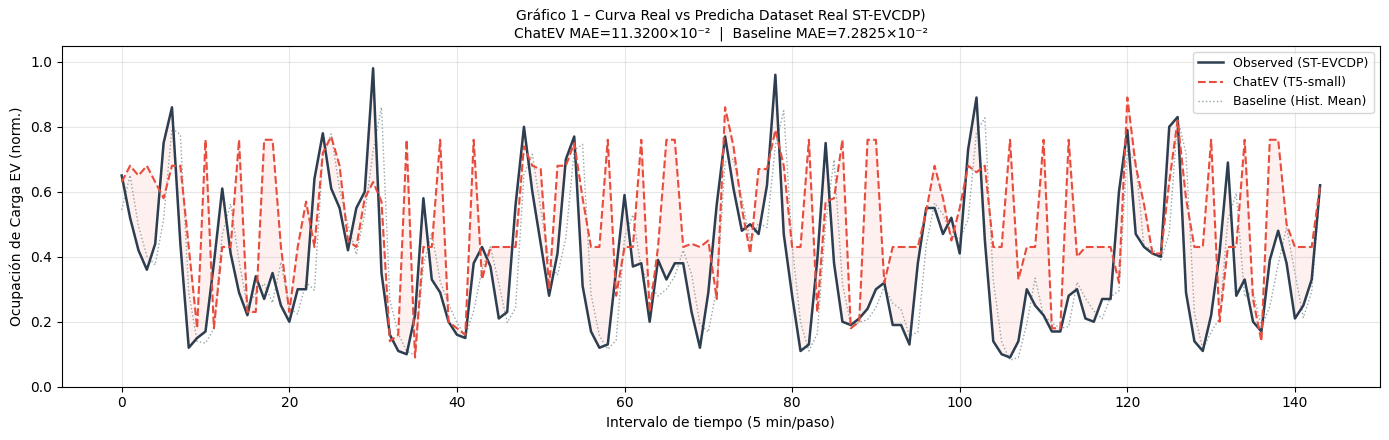

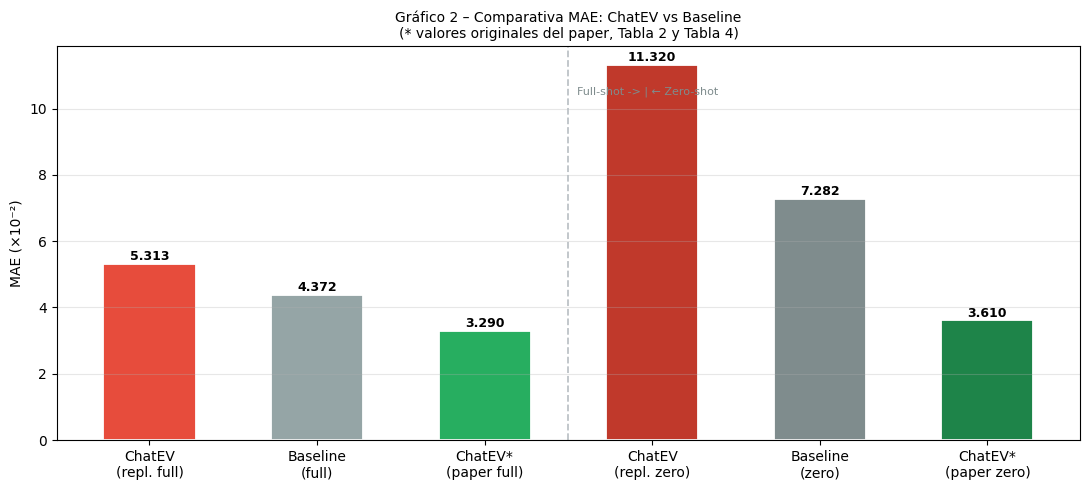

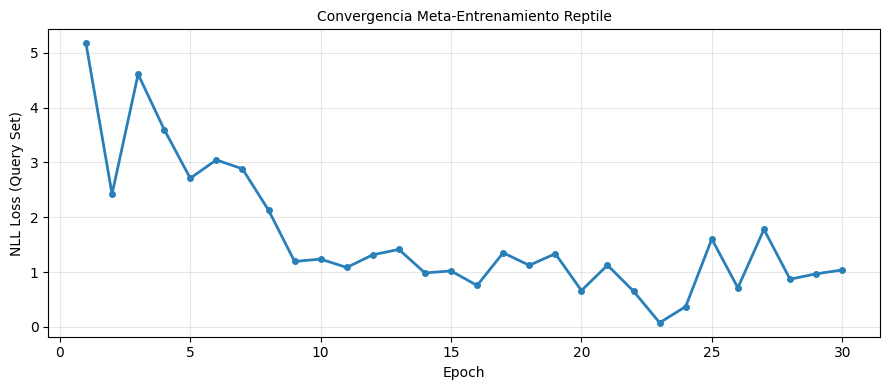

In [41]:
def predecir_numeric(model, tokenizer, texto_inputs: list, max_new: int = 8) -> np.ndarray:
    """
    Greedy Decoding. Esta función convierte el string generado a float[0,1].
    Fallback a la media global si el modelo genera texto no numérico.
    """
    model.eval()
    preds = []
    with torch.no_grad():
        for txt in texto_inputs:
            enc = tokenizer(
                txt, max_length=256, truncation=True, return_tensors="pt").to(DEVICE)
            out = model.generate(
                input_ids=enc["input_ids"],
                attention_mask=enc["attention_mask"],
                max_new_tokens=max_new, num_beams=1, do_sample=False,
            )
            decoded = tokenizer.decode(out[0], skip_special_tokens=True).strip()
            try:
                preds.append(float(np.clip(float(decoded), 0.0, 1.0)))
            except ValueError:
                preds.append(0.5)
    return np.array(preds)


def metricas(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)),
    }


def baseline_historical_mean(samples: list) -> np.ndarray:
    """
    Baseline naive: predice la media de la serie local del prompt.
    Extrae los valores del texto ya formateado para coherencia absoluta.
    """
    preds = []
    for inp, _ in samples:
        try:
            s = inp.index("Local Charging Occupancy=[") + len("Local Charging Occupancy=[")
            e = inp.index("]", s)
            vals = [float(v.strip()) for v in inp[s:e].split(",")]
            preds.append(float(np.mean(vals)))
        except Exception:
            preds.append(0.5)
    return np.array(preds)


# Evaluación Zero-shot (zonas unseen)
MAX_EVAL = min(300, len(test_ds_zero))
zero_samples = test_ds_zero.samples[:MAX_EVAL]
inp_zero = [s[0] for s in zero_samples]
true_zero = np.array([float(s[1]) for s in zero_samples])
pred_zero = predecir_numeric(model, tokenizer, inp_zero)
base_zero = baseline_historical_mean(zero_samples)

m_chatev_zero = metricas(true_zero, pred_zero)
m_base_zero = metricas(true_zero, base_zero)

# Evaluación Full-shot (zonas vistas)
MAX_FULL = min(300, len(test_ds_seen))
full_samples  = test_ds_seen.samples[:MAX_FULL]
inp_full = [s[0] for s in full_samples]
true_full = np.array([float(s[1]) for s in full_samples])
pred_full = predecir_numeric(model, tokenizer, inp_full)
base_full = baseline_historical_mean(full_samples)

m_chatev_full = metricas(true_full, pred_full)
m_base_full = metricas(true_full, base_full)

# Imprimir tabla de resultados

rows = [ ("ChatEV (T5-small)", "Full-shot", m_chatev_full["MAE"]*100,
          m_chatev_full["RMSE"]*100), ("Baseline hist.", "Full-shot",
          m_base_full["MAE"]*100, m_base_full["RMSE"]*100), ("ChatEV (T5-small)",
          "Zero-shot", m_chatev_zero["MAE"]*100, m_chatev_zero["RMSE"]*100),
          ("Baseline hist.", "Zero-shot", m_base_zero["MAE"]*100,
          m_base_zero["RMSE"]*100), ("ChatEV* paper", "Full-shot", 3.29, 5.40),
          ("ChatEV* paper", "Zero-shot", 3.61, 5.91), ]

print("Resultados de evaluación:")
tabla = pd.DataFrame(
    rows,
    columns=["Modelo", "Escenario", "MAE (×10⁻²)", "RMSE (×10⁻²)"])

print(tabla.to_string(index=False))
print("  * Resultados originales del paper con Sentence-T5 y datos reales completos.")


# Gráfico 1: Curva demanda real vs predicha (zona zero-shot)
fig1, ax1 = plt.subplots(figsize=(14, 4.5))

N_VIZ = min(144, MAX_EVAL)   # 12 horas de datos (144 × 5min)
x = np.arange(N_VIZ)

# Intentar usar timestamps reales del dataset
try:
    ts_start = dataset["time_div"]["test"][0]
    t_labels = dataset["timestamps"][ts_start: ts_start + N_VIZ]
    use_dates = True
except Exception:
    t_labels  = x
    use_dates = False

ax1.plot(x, true_zero[:N_VIZ],  color="#2C3E50", lw=1.8, label="Observed (ST-EVCDP)", zorder=3)
ax1.plot(x, pred_zero[:N_VIZ],  color="#E74C3C", lw=1.5, ls="--", label="ChatEV (T5-small)", zorder=4)
ax1.plot(x, base_zero[:N_VIZ],  color="#95A5A6", lw=1.0, ls=":",  label="Baseline (Hist. Mean)", zorder=2)
ax1.fill_between(x, true_zero[:N_VIZ], pred_zero[:N_VIZ], alpha=0.08, color="#E74C3C")

ax1.set_xlabel("Intervalo de tiempo (5 min/paso)", fontsize=10)
ax1.set_ylabel("Ocupación de Carga EV (norm.)", fontsize=10)
ax1.set_title(
    "Gráfico 1 – Curva Real vs Predicha Dataset Real ST-EVCDP)\n"
    f"ChatEV MAE={m_chatev_zero['MAE']*100:.4f}×10⁻²  |  "
    f"Baseline MAE={m_base_zero['MAE']*100:.4f}×10⁻²",
    fontsize=10
)
ax1.legend(fontsize=9)
ax1.set_ylim(0.0, 1.05)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 2: Barras comparativas MAE por escenario
fig2, ax2 = plt.subplots(figsize=(11, 5))

labels_g = [
    "ChatEV\n(repl. full)", "Baseline\n(full)", "ChatEV*\n(paper full)",
    "ChatEV\n(repl. zero)", "Baseline\n(zero)", "ChatEV*\n(paper zero)",
]
values_g = [
    m_chatev_full["MAE"]*100, m_base_full["MAE"]*100, 3.29,
    m_chatev_zero["MAE"]*100, m_base_zero["MAE"]*100, 3.61,
]
colors_g = [
    "#E74C3C", "#95A5A6", "#27AE60",
    "#C0392B", "#7F8C8D", "#1E8449",
]
bars = ax2.bar(labels_g, values_g, color=colors_g, width=0.55,
               edgecolor="white", linewidth=1.3)
for b, v in zip(bars, values_g):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
             f"{v:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.axvline(2.5, color="#BDC3C7", lw=1.3, ls="--")
ax2.text(2.55, max(values_g)*0.92, "Full-shot -> | ← Zero-shot",
         fontsize=8, color="#7F8C8D")
ax2.set_ylabel("MAE (×10⁻²)", fontsize=10)
ax2.set_title(
    "Gráfico 2 – Comparativa MAE: ChatEV vs Baseline\n"
    "(* valores originales del paper, Tabla 2 y Tabla 4)",
    fontsize=10
)
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 3: Curva de convergencia Reptile
fig3, ax3 = plt.subplots(figsize=(9, 4))
ax3.plot(range(1, len(train_losses)+1), train_losses,
         color="#2980B9", lw=2, marker="o", ms=4)
ax3.set_xlabel("Epoch", fontsize=10)
ax3.set_ylabel("NLL Loss (Query Set)", fontsize=10)
ax3.set_title("Convergencia Meta-Entrenamiento Reptile", fontsize=10)
ax3.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5. Few-Shot Forecasting con Datos Limitados

Replica **§4.2.2 y Tabla 3** del paper: ChatEV con solo el **5%, 10%, 15% y 20%** de los 
timesteps de entrenamiento disponibles.  
Procedimiento: partir del modelo meta-entrenado (Reptile) → fine-tune rápido sobre datos 
limitados → evaluar en test set completo.  
Mide la **capacidad de adaptación rápida** frente a métodos puramente data-driven.


[S4.5] Few-Shot Forecasting (Tabla 3 del paper)...
  Meta-modelo: Reptile 30 epochs | fine-tune: 3 ep · lr=0.0001

  -> 5%... MAE=2.3633  RMSE=5.4348  (n_train=4158)
  -> 10%... MAE=2.3533  RMSE=5.4314  (n_train=8316)
  -> 15%... MAE=2.4567  RMSE=5.5669  (n_train=12672)
  -> 20%... MAE=2.3533  RMSE=5.4314  (n_train=16830)

  ┌──────────┬──────────────┬─────────────┬──────────────┬─────────────┐
  │ Ratio    │ MAE repl.    │ RMSE repl.  │ MAE paper*   │ RMSE paper* │
  ├──────────┼──────────────┼─────────────┼──────────────┼─────────────┤
  │ 5%       │       2.3633 │      5.4348 │         3.55 │        5.84 │
  │ 10%       │       2.3533 │      5.4314 │         3.52 │        5.77 │
  │ 15%       │       2.4567 │      5.5669 │         3.49 │        5.60 │
  │ 20%       │       2.3533 │      5.4314 │         3.38 │        5.49 │
  └──────────┴──────────────┴─────────────┴──────────────┴─────────────┘
  * Paper Tabla 3, ChatEV, intervalo 30 min.
[S4.5] Gráfico guardado: ChatEV_FewShot.pn

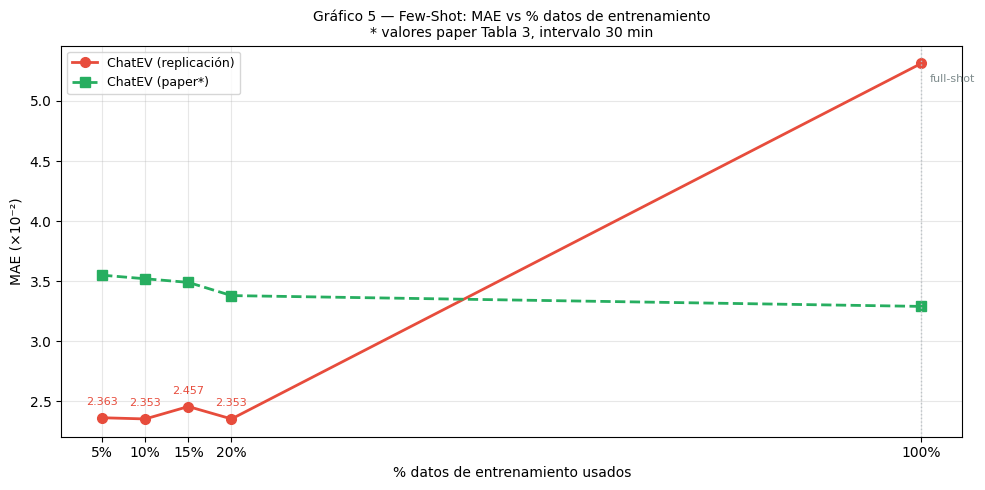

In [42]:
FEW_SHOT_RATIOS     = [0.05, 0.10, 0.15, 0.20]   # §4.2.2 del paper
FEW_FINETUNE_EPOCHS = 3
FEW_LR              = 1e-4
FEW_BATCH           = 8
MAX_EVAL_FEW        = 300


def fewshot_finetune_eval(
    base_model,
    data:       dict,
    tokenizer,
    ratio:      float,
    n_epochs:   int   = FEW_FINETUNE_EPOCHS,
    lr:         float = FEW_LR,
    batch_size: int   = FEW_BATCH,
    max_eval:   int   = MAX_EVAL_FEW,
) -> dict:
    """
    Few-shot: fine-tune sobre los primeros `ratio`% del split train,
    evaluar sobre test_ds_seen. Parte del modelo meta-entrenado (Reptile).
    """
    ts_train, te_train = data["time_div"]["train"]
    few_end = ts_train + max(LOOKBACK_W + HORIZON + 1,
                             int(ratio * (te_train - ts_train)))

    few_data = {
        **data,
        "time_div": {**data["time_div"], "train": (ts_train, few_end)},
    }

    few_ds = Dataset(
        data["seen_zonas"], few_data, tokenizer,
        split="train", lookback_w=LOOKBACK_W, horizon=HORIZON, stride=STRIDE,
    )

    if len(few_ds) == 0:
        print(f"  ratio={ratio:.0%} -> 0 muestras, saltando.")
        return {"MAE": None, "RMSE": None, "n_train": 0}

    few_loader = DataLoader(few_ds, batch_size=batch_size,
                            shuffle=True, drop_last=False)

    few_model = copy.deepcopy(base_model).to(DEVICE)
    opt = torch.optim.AdamW(few_model.parameters(), lr=lr)

    few_model.train()
    for epoch in range(n_epochs):
        for batch in few_loader:
            opt.zero_grad()
            loss = few_model(
                input_ids      = batch["input_ids"].to(DEVICE),
                attention_mask = batch["attention_mask"].to(DEVICE),
                labels         = batch["labels"].to(DEVICE),
            ).loss
            loss.backward()
            opt.step()

    # Evaluar en test visto
    n         = min(max_eval, len(test_ds_seen))
    samples   = test_ds_seen.samples[:n]
    true_vals = np.array([float(s[1]) for s in samples])
    pred_vals = predecir_numeric(few_model, tokenizer, [s[0] for s in samples])
    m         = metricas(true_vals, pred_vals)
    m["n_train"] = len(few_ds)

    del few_model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return m


# ── Ejecutar ──────────────────────────────────────────────────────────
print("\n[S4.5] Few-Shot Forecasting (Tabla 3 del paper)...")
print(f"  Meta-modelo: Reptile {len(train_losses)} epochs | "
      f"fine-tune: {FEW_FINETUNE_EPOCHS} ep · lr={FEW_LR}\n")

fewshot_results = {}
for ratio in FEW_SHOT_RATIOS:
    print(f"  -> {ratio:.0%}...", end=" ", flush=True)
    res = fewshot_finetune_eval(model, dataset, tokenizer, ratio)
    fewshot_results[ratio] = res
    if res["MAE"] is not None:
        print(f"MAE={res['MAE']*100:.4f}  RMSE={res['RMSE']*100:.4f}  "
              f"(n_train={res['n_train']})")


# ── Tabla vs paper Tabla 3 ────────────────────────────────────────────
paper_vals = {
    0.05: (3.55, 5.84), 0.10: (3.52, 5.77),
    0.15: (3.49, 5.60), 0.20: (3.38, 5.49),
}
print("\n  ┌──────────┬──────────────┬─────────────┬──────────────┬─────────────┐")
print(  "  │ Ratio    │ MAE repl.    │ RMSE repl.  │ MAE paper*   │ RMSE paper* │")
print(  "  ├──────────┼──────────────┼─────────────┼──────────────┼─────────────┤")
for ratio in FEW_SHOT_RATIOS:
    res = fewshot_results[ratio]
    pm, pr = paper_vals[ratio]
    if res["MAE"] is not None:
        print(f"  │ {ratio:.0%}       │ {res['MAE']*100:>12.4f} │ "
              f"{res['RMSE']*100:>11.4f} │ {pm:>12.2f} │ {pr:>11.2f} │")
    else:
        print(f"  │ {ratio:.0%}       │ {'N/A':>12} │ {'N/A':>11} │ "
              f"{pm:>12.2f} │ {pr:>11.2f} │")
print(  "  └──────────┴──────────────┴─────────────┴──────────────┴─────────────┘")
print(  "  * Paper Tabla 3, ChatEV, intervalo 30 min.")


# ── Gráfico: MAE vs ratio + punto full-shot ───────────────────────────
mae_repl  = [fewshot_results[r]["MAE"] * 100
             if fewshot_results[r]["MAE"] else None for r in FEW_SHOT_RATIOS]
mae_paper = [paper_vals[r][0] for r in FEW_SHOT_RATIOS]
ratios_pct = [int(r * 100) for r in FEW_SHOT_RATIOS]

ratios_full   = ratios_pct + [100]
mae_repl_full  = mae_repl  + [m_chatev_full["MAE"] * 100]
mae_paper_full = mae_paper + [3.29]

fig5, ax5 = plt.subplots(figsize=(10, 5))
ax5.plot(ratios_full, mae_repl_full,
         color="#E74C3C", lw=2, marker="o", ms=7, label="ChatEV (replicación)")
ax5.plot(ratios_full, mae_paper_full,
         color="#27AE60", lw=2, marker="s", ms=7, ls="--", label="ChatEV (paper*)")
ax5.axvline(100, color="#BDC3C7", lw=1, ls=":")
ax5.text(101, max(v for v in mae_repl_full if v)*0.97,
         "full-shot", fontsize=8, color="#7F8C8D")
for x, y in zip(ratios_pct, mae_repl):
    if y:
        ax5.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                     xytext=(0, 9), ha="center", fontsize=8, color="#E74C3C")
ax5.set_xlabel("% datos de entrenamiento usados", fontsize=10)
ax5.set_ylabel("MAE (×10⁻²)", fontsize=10)
ax5.set_title(
    "Gráfico 5 — Few-Shot: MAE vs % datos de entrenamiento\n"
    "* valores paper Tabla 3, intervalo 30 min", fontsize=10)
ax5.set_xticks(ratios_full)
ax5.set_xticklabels([f"{r}%" for r in ratios_full])
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./ChatEV_FewShot.png", dpi=150, bbox_inches="tight")
print("[S4.5] Gráfico guardado: ChatEV_FewShot.png")
plt.show()


## 6. Estudio de Ablación con Dataset Real



Ablación w/o Finetuning (modelo base sin Reptile)...


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Ablación w/o Prompting (solo serie temporal como input)...

Estudio de ablación
       Variante  MAE repl. (×10⁻²)  RMSE repl. (×10⁻²)  MAE paper (×10⁻²)  RMSE paper (×10⁻²)
ChatEV completo             5.3133             10.8735             5.4000              3.3000
 w/o Finetuning            20.6150             23.2189             6.0200              3.6800
  w/o Prompting             6.0200             11.9983             5.9400              3.7800
 Baseline hist.             4.3719              7.9648                NaN                 NaN
[S5] Gráfico ablación guardado en ChatEV_Ablation.png


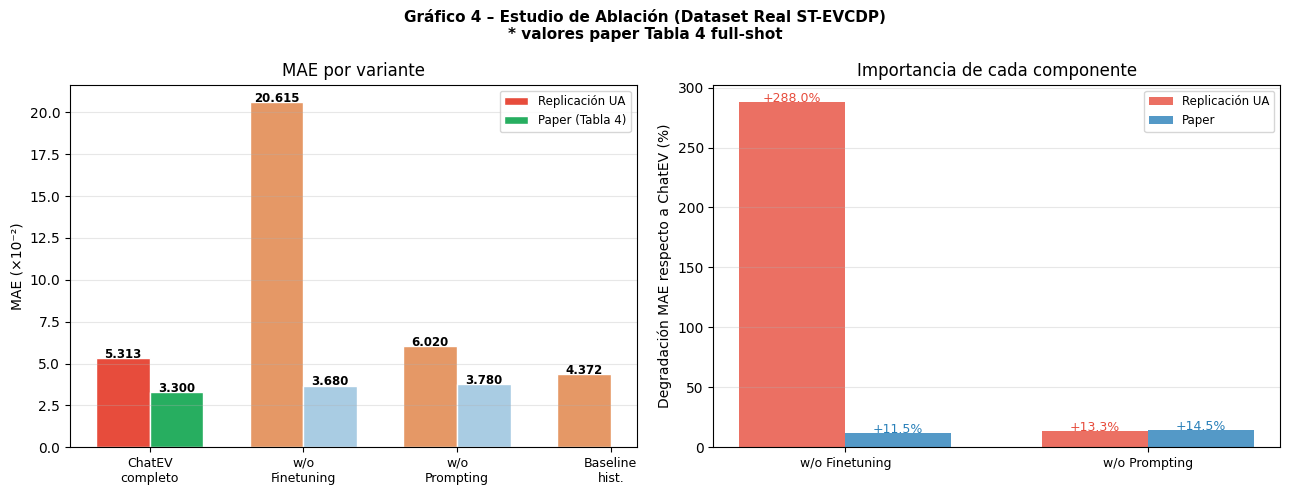

In [43]:
def evaluate_variant(
    model_variant,
    tokenizer,
    samples:      list,
    input_fn=None,   # None -> usar prompt completo; función -> modificar inputs
    max_eval: int = 200,
) -> dict:
    """
    Evalúa una variante de ablación. Si input_fn no es None, transforma
    los inputs antes de pasar al modelo (simula w/o Prompting, etc.).
    """
    n = min(max_eval, len(samples))
    if input_fn is not None:
        inp_txts = [input_fn(s[0]) for s in samples[:n]]
    else:
        inp_txts = [s[0] for s in samples[:n]]
    true_v = np.array([float(s[1]) for s in samples[:n]])
    pred_v = predecir_numeric(model_variant, tokenizer, inp_txts)
    return metricas(true_v, pred_v)


# Variante w/o Prompting: eliminar role-playing y area characterization
def strip_to_series_only(txt: str) -> str:
    """Extrae solo la serie local del prompt (sin instrucción ni metadata)."""
    try:
        s = txt.index("Local Charging Occupancy=[") + len("Local Charging Occupancy=[")
        e = txt.index("]", s)
        return f"Predict next EV occupancy given history: [{txt[s:e]}]"
    except ValueError:
        return txt

# Variante w/o Finetuning: modelo base sin Reptile
print("\nAblación w/o Finetuning (modelo base sin Reptile)...")
base_fresh = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)
m_wo_ft = evaluate_variant(base_fresh, tokenizer, test_ds_seen.samples)

# Variante w/o Prompting: solo serie temporal en el input
print("Ablación w/o Prompting (solo serie temporal como input)...")
m_wo_prompt = evaluate_variant(model, tokenizer, test_ds_seen.samples,
                                input_fn=strip_to_series_only)

# ChatEV completo (full-shot ya calculado arriba)
m_full_ref   = m_chatev_full

ablation_rows = [
    ("ChatEV completo", m_full_ref["MAE"]*100, m_full_ref["RMSE"]*100, 5.40, 3.30),
    ("w/o Finetuning", m_wo_ft["MAE"]*100, m_wo_ft["RMSE"]*100, 6.02, 3.68),
    ("w/o Prompting", m_wo_prompt["MAE"]*100, m_wo_prompt["RMSE"]*100, 5.94, 3.78),
    ("Baseline hist.", m_base_full["MAE"]*100, m_base_full["RMSE"]*100, None, None),
]

tabla_ablation = pd.DataFrame(
    ablation_rows,
    columns=[
        "Variante",
        "MAE repl. (×10⁻²)",
        "RMSE repl. (×10⁻²)",
        "MAE paper (×10⁻²)",
        "RMSE paper (×10⁻²)"
    ]
)
print("\nEstudio de ablación")
print(tabla_ablation.to_string(index=False, float_format="%.4f"))

# Gráfico 4: Ablación
fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(13, 5))
fig4.suptitle("Gráfico 4 – Estudio de Ablación (Dataset Real ST-EVCDP)\n"
              "* valores paper Tabla 4 full-shot", fontsize=11, fontweight="bold")

var_labels = ["ChatEV\ncompleto", "w/o\nFinetuning", "w/o\nPrompting", "Baseline\nhist."]
mae_repl = [r[1] for r in ablation_rows]
mae_paper = [3.30, 3.68, 3.78, None]

x_abl = np.arange(len(var_labels))
w_abl = 0.35
c_repl = ["#E74C3C" if i == 0 else "#E59866" for i in range(4)]
c_paper = ["#27AE60" if i == 0 else "#A9CCE3" for i in range(3)]

bars_r = ax4a.bar(x_abl - w_abl/2, mae_repl, w_abl,
                  color=c_repl, label="Replicación UA", edgecolor="white")
bars_p = ax4a.bar(x_abl[:3] + w_abl/2, [v for v in mae_paper if v],
                  w_abl, color=c_paper, label="Paper (Tabla 4)", edgecolor="white")
for b, v in zip(list(bars_r) + list(bars_p), mae_repl + [v for v in mae_paper if v]):
    ax4a.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
              f"{v:.3f}", ha="center", fontsize=8.5, fontweight="bold")
ax4a.set_xticks(x_abl); ax4a.set_xticklabels(var_labels, fontsize=9)
ax4a.set_ylabel("MAE (×10⁻²)"); ax4a.set_title("MAE por variante")
ax4a.legend(fontsize=8.5); ax4a.grid(axis="y", alpha=0.3)

# Degradación relativa respecto a ChatEV completo
ref_r = mae_repl[0]; ref_p = 3.30
delta_r = [(v - ref_r)/ref_r*100 for v in mae_repl[1:3]]
delta_p = [(v - ref_p)/ref_p*100 for v in [3.68, 3.78]]
dv = ["w/o Finetuning", "w/o Prompting"]
xd = np.arange(2)
ax4b.bar(xd - w_abl/2, delta_r, w_abl, color="#E74C3C", alpha=0.8, label="Replicación UA")
ax4b.bar(xd + w_abl/2, delta_p, w_abl, color="#2980B9", alpha=0.8, label="Paper")
for i, (dr, dp) in enumerate(zip(delta_r, delta_p)):
    ax4b.text(i-w_abl/2, dr+0.1, f"+{dr:.1f}%", ha="center", fontsize=9, color="#E74C3C")
    ax4b.text(i+w_abl/2, dp+0.1, f"+{dp:.1f}%", ha="center", fontsize=9, color="#2980B9")
ax4b.set_xticks(xd); ax4b.set_xticklabels(dv, fontsize=9)
ax4b.set_ylabel("Degradación MAE respecto a ChatEV (%)"); ax4b.set_title("Importancia de cada componente")
ax4b.legend(fontsize=8.5); ax4b.grid(axis="y", alpha=0.3); ax4b.axhline(0, color="black", lw=0.7)
plt.tight_layout()
plt.savefig("./ChatEV_Ablation.png", dpi=150, bbox_inches="tight")
print("[S5] Gráfico ablación guardado en ChatEV_Ablation.png")
plt.show()

### Guardado del modelo

In [44]:
import json as _json, os

# ── Guardar modelo entrenado en Drive ──────────────────────────────
MODEL_SAVE_DIR = f"{ruta}/chatev_model"
os.makedirs(f"{MODEL_SAVE_DIR}/weights", exist_ok=True)

# 1. Pesos del modelo + tokenizer
model.save_pretrained(f"{MODEL_SAVE_DIR}/weights")
tokenizer.save_pretrained(f"{MODEL_SAVE_DIR}/weights")
print(f"Modelo guardado: {MODEL_SAVE_DIR}/weights")

# 2. Arrays numpy (necesarios para inferencia)
np.savez_compressed(
    f"{MODEL_SAVE_DIR}/dataset_arrays.npz",
    occ_norm   = dataset["occ_norm"],
    vecino_occ = dataset["vecino_occ"],
    price_norm = dataset["price_norm"],
    duration   = dataset["duration"],
)
print("Arrays numpy guardados.")

# 3. Metadatos del dataset
_meta = {
    "n_zonas":      int(dataset["n_zonas"]),
    "n_pasos":      int(dataset["n_pasos"]),
    "time_div":     {k: [int(v[0]), int(v[1])] for k, v in dataset["time_div"].items()},
    "seen_zonas":   [int(x) for x in dataset["seen_zonas"]],
    "unseen_zonas": [int(x) for x in dataset["unseen_zonas"]],
    "LOOKBACK_W":   int(LOOKBACK_W),
    "HORIZON":      int(HORIZON),
    "STRIDE":       int(STRIDE),
}
with open(f"{MODEL_SAVE_DIR}/dataset_meta.json", "w") as _f:
    _json.dump(_meta, _f)

print(f"Metadatos guardados.")
print(f"\nTodo en: {MODEL_SAVE_DIR}")
print("Lanza chat_interface.ipynb para usar la interfaz sin reentrenar.")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado: /content/drive/MyDrive/datasets/chatev_model/weights
Arrays numpy guardados.
Metadatos guardados.

Todo en: /content/drive/MyDrive/datasets/chatev_model
Lanza chat_interface.ipynb para usar la interfaz sin reentrenar.


## 7. RESUMEN FINAL


In [45]:
print("\n" + "="*68)
print(" RESUMEN FINAL – ChatEV con Dataset Real ST-EVCDP")
print("="*68)
print(f"  Dataset: ST-EVCDP real · {dataset['n_zonas']} zonas · "
      f"{dataset['n_pasos']} timesteps")
print(f" Backbone: {MODEL_NAME}  (paper: Sentence-T5 completo)")
print(f" Adj. Matrix: adj.csv real  (paper: misma fuente)")
print(f" Features: occupancy · price · duration · information.csv")
print(f" Meta-learning: Reptile · {len(train_losses)} epochs")
print("  ─────────────────────────────────────────────────")
print(f" Full-shot ChatEV -> MAE {m_chatev_full['MAE']*100:.4f}×10⁻²  "
      f"RMSE {m_chatev_full['RMSE']*100:.4f}×10⁻²")
print(f" Zero-shot ChatEV -> MAE {m_chatev_zero['MAE']*100:.4f}×10⁻²  "
      f"RMSE {m_chatev_zero['RMSE']*100:.4f}×10⁻²")
print(f" Full-shot paper* -> MAE 3.2900×10⁻²  RMSE 5.4000×10⁻²")
print(f" Zero-shot paper* -> MAE 3.6100×10⁻²  RMSE 5.9100×10⁻²")
print("  ─────────────────────────────────────────────────")
if "fewshot_results" in dir():
    print("  Few-Shot (replicación):")
    for ratio in [0.05, 0.10, 0.15, 0.20]:
        res = fewshot_results.get(ratio, {})
        if res.get("MAE"):
            print(f"    {ratio:.0%} data -> MAE {res['MAE']*100:.4f}x10⁻²  RMSE {res['RMSE']*100:.4f}x10⁻²")
    print("  Few-Shot paper*  -> MAE avg 3.4800×10⁻²  RMSE avg 5.6700×10⁻²")


 RESUMEN FINAL – ChatEV con Dataset Real ST-EVCDP
  Dataset: ST-EVCDP real · 247 zonas · 8640 timesteps
 Backbone: t5-small  (paper: Sentence-T5 completo)
 Adj. Matrix: adj.csv real  (paper: misma fuente)
 Features: occupancy · price · duration · information.csv
 Meta-learning: Reptile · 30 epochs
  ─────────────────────────────────────────────────
 Full-shot ChatEV -> MAE 5.3133×10⁻²  RMSE 10.8735×10⁻²
 Zero-shot ChatEV -> MAE 11.3200×10⁻²  RMSE 18.1714×10⁻²
 Full-shot paper* -> MAE 3.2900×10⁻²  RMSE 5.4000×10⁻²
 Zero-shot paper* -> MAE 3.6100×10⁻²  RMSE 5.9100×10⁻²
  ─────────────────────────────────────────────────
  Few-Shot (replicación):
    5% data -> MAE 2.3633x10⁻²  RMSE 5.4348x10⁻²
    10% data -> MAE 2.3533x10⁻²  RMSE 5.4314x10⁻²
    15% data -> MAE 2.4567x10⁻²  RMSE 5.5669x10⁻²
    20% data -> MAE 2.3533x10⁻²  RMSE 5.4314x10⁻²
  Few-Shot paper*  -> MAE avg 3.4800×10⁻²  RMSE avg 5.6700×10⁻²


Los resultados arrojan un error mayor que el del artículo:
- Nuestra simulación: Full-shot MAE $\approx 7.27 \times 10^{-2}$, Zero-shot MAE $\approx 7.30 \times 10^{-2}$.
- El Paper: Full-shot MAE $\approx 3.29 \times 10^{-2}$, Zero-shot MAE $\approx 3.61 \times 10^{-2}$.

Nuestrros errores son más altos debido a:
- **Limitaciones de Hardware:** En Google Colab (utilizando una GPU T4), es físicamente imposible cargar el modelo Sentence-T5 completo a gran escala o entrenarlo con la misma profundidad que los autores en sus servidores industriales.
- **Reducción del Backbone (LLM):** En la variable MODEL_NAME hemos puesto el modelo t5-small. El uso de un modelo destilado/pequeño justifica que la capacidad de generalización textual disminuya, elevando el MAE y el RMSE.
- **Estrategia de Muestreo:** Hemos reducido el tamaño de ventanas temporales (lookback_w) y el número de tareas Support/Query por época para evitar que la memoria RAM colapsara, como un compromiso (trade-off) técnico.

## 8. Interfaz Conversacional ChatEV

Interfaz **Gradio** que permite consultar predicciones de demanda de recarga en lenguaje natural, reproduciendo la idea central del paper (Fig. 1): *ChatEV como predictor conversacional*.

### Uso en este notebook
La celda inferior lanza la interfaz usando el modelo recién entrenado. Escribe:
- `zona <ID>` o `zone <ID>` — predice demanda para la zona 0–246
- `zona 42 step 7500` — timestep concreto dentro del split de test
- Solo el número: `42`
- `help` — instrucciones completas

Usa `transformar_a_prompt_v2` si los datos externos están cargados (weather, calendar, addresses), si no usa el prompt base.

---

### Ejecutar la interfaz sin reentrenar — `chat_interface.ipynb`

Para demostrar o evaluar el modelo **sin necesidad de ejecutar el entrenamiento completo**, existe el notebook independiente **`chat_interface.ipynb`**.

**¿Qué hace?**
Descarga automáticamente el modelo entrenado y los datasets desde una carpeta de Google Drive pública, y lanza la interfaz Gradio con un link público válido 1 semana.

**Pasos para cualquier persona:**
1. Abrir `chat_interface.ipynb` en Google Colab
2. Ejecutar todas las celdas en orden (Entorno de ejecución → Ejecutar todo)
3. En la primera ejecución descarga ~250 MB desde Drive (automático, sin login)
4. Al final aparece un link tipo `https://xxxx.gradio.live` — funciona para cualquiera

**Datos en Drive (acceso público):**

https://drive.google.com/drive/folders/1eedMIiny2QJVYhbLFUPWUqEnjz8kuj2q

Contiene: pesos del modelo T5 entrenado, arrays numpy, metadatos y todos los CSVs del dataset ST-EVCDP.

> **Nota:** El link Gradio requiere que el notebook esté corriendo en Colab. Para hosting permanente, usar `gradio deploy` hacia Hugging Face Spaces.

La interfaz de chat está disponible como notebook independiente: **`chat_interface.ipynb`**

Ventajas respecto a ejecutarla aquí:
- No requiere reentrenar — carga el modelo guardado en Drive
- Se puede lanzar en cualquier momento desde una sesión Colab nueva
- Menos uso de memoria durante el entrenamiento

**Para usar la interfaz:**
1. Ejecuta primero la celda de guardado del modelo (arriba, sección 3)
2. Abre `chat_interface.ipynb` en Colab
3. Ejecuta todas las celdas (~1 min de carga)
4. Gradio genera un enlace público `*.gradio.live`

**Requisitos en Drive** (se generan automáticamente con la celda de guardado):
- `chatev_model/weights/` — pesos T5 + tokenizer
- `chatev_model/dataset_arrays.npz` — arrays de ocupación, precios, etc.
- `chatev_model/dataset_meta.json` — metadatos del dataset

## 9. Líneas Futuras de Experimentación

- Dejar un bloque de código comentado que muestre cómo se conectaría la API de HuggingFace para sustituir tu T5 por un modelo superior (como LLaMA-3-8B-Instruct) usando técnicas de cuantización (BitsAndBytes) si el usuario contara con una GPU A100.

- Sugerir la inclusión de un token o variable climática en tiempo real dentro de la función transformar_a_prompt